# Análisis Completo de Señales EMG desde Archivos CSV

Este notebook implementa un análisis exhaustivo de señales de electromiografía (EMG) registradas en formato CSV por equipos Noraxon.

## Contenido:
1. **Importación de librerías** - Configuración del entorno
2. **Configuración y funciones base** - Parámetros del filtrado
3. **Carga de datos** - Lectura de archivos CSV
4. **Procesamiento previo** - Eliminación de ruido y artefactos
5. **Características temporales** - Análisis en el dominio del tiempo
6. **Características espectrales** - Análisis en el dominio de la frecuencia
7. **Detección de fatiga** - Spectral compression y análisis MDF
8. **Visualización** - Gráficos y reportes
9. **Exportación** - Guardado de resultados

## Objetivo:
Proporcionar un pipeline completo para:
- Filtrar y limpiar señales EMG
- Extraer características relevantes (temporales y espectrales)
- Normalizar a MVC (Maximal Voluntary Contraction)
- Detectar fatiga muscular
- Generar reportes visuales y numéricos

## Sección 1: Importar Librerías Necesarias

Instalaremos y cargaremos todas las librerías que necesitamos para:
- **pandas**: Lectura y manipulación de archivos CSV
- **numpy**: Operaciones matemáticas y algebraicas
- **matplotlib**: Visualización de gráficos
- **scipy.signal**: Filtrado digital y análisis espectral

In [ ]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, welch, correlate, sosfilt, sosfilt_zi
from statistics import mean
import math
import os
from pathlib import Path

# Configurar matplotlib para mejor visualización
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

print("[OK] Todas las librerias cargadas correctamente")

[OK] Todas las librerias cargadas correctamente


## Sección 2: Configuración de Parámetros

### Configuración de filtrado y procesamiento

Parámetros optimizados para análisis EMG:

| Parámetro | Valor | Justificación |
|-----------|-------|---------------|
| **Frecuencia de muestreo** | 2000 Hz | Adecuada para capturar contenido espectral EMG |
| **Filtro pasa-alto** | 20 Hz | Elimina artefactos de movimiento |
| **Filtro pasa-bajo** | 450 Hz | Elimina ruido de alta frecuencia |
| **Cutoff envolvente** | 6 Hz | Captura dinámica de contracciones musculares |
| **Umbral de fatiga** | 90% (MDF) | Criterio para detectar fatiga muscular |

### ¿Por qué estos valores?

- **20-450 Hz**: Rango óptimo que contiene la mayoría de la información útil de EMG superficial
- **6 Hz envolvente**: Balance entre suavizado y respuesta dinámica
- **90% MDF**: Una caída del 10% en la frecuencia mediana indica fatiga significativa

In [ ]:
# --- CONFIGURACIÓN GLOBAL ---
DEFAULT_FS = 2000  # Frecuencia de muestreo (Hz)
CUTOFF_LOW = 20    # Paso alto: elimina artefactos de movimiento
CUTOFF_HIGH = 450  # Paso bajo: elimina ruido alta frecuencia
ENVELOPE_CUTOFF = 6  # Paso bajo envolvente
FATIGUE_THRESHOLD = 0.9  # 90% MDF inicial = criterio fatiga


def remove_dc_offset(data: np.ndarray) -> np.ndarray:
    """
    Elimina la componente DC (media) de la señal.
    
    La componente DC es el valor promedio de la señal.
    Al removerla, centramos la señal alrededor de cero.
    """
    return data - np.mean(data)


def estimate_mvc(samples: list, method: str = "peak") -> float:
    """
    Estima MVC (Maximal Voluntary Contraction) de muestras de envolvente EMG.
    
    La normalización a MVC es fundamental para:
    - Comparar activación entre sujetos
    - Compensar variabilidad inter-sujeto
    - Expresar activación como % de capacidad máxima
    
    Métodos implementados:
        - peak: Valor máximo absoluto
          Ventaja: Simple, rápido
          Desventaja: Sensible a picos de ruido
          
        - 95perc: Percentil 95 
          Ventaja: Robusto a outliers
          Desventaja: Requiere suficientes muestras (>100)
          
        - mean_top10: Media del 10% superior
          Ventaja: Muy robusto al ruido
          Desventaja: Puede subestimar MVC real
    
    Args:
        samples: Lista de valores de envolvente EMG (µV)
        method: Método de estimación ("peak", "95perc", "mean_top10")
    
    Returns:
        float: Valor MVC en microvoltios (µV)
    """
    if not samples:
        return 0.0
    arr = sorted(samples)
    if method == "peak":
        return float(max(arr))
    if method == "95perc":
        idx = min(len(arr) - 1, math.ceil(0.95 * len(arr)) - 1)
        return float(arr[idx])
    if method == "mean_top10":
        n = max(1, int(0.1 * len(arr)))
        return float(np.mean(arr[-n:]))
    # fallback
    return float(max(arr))


def butter_bandpass_filter(data: np.ndarray, lowcut: float, highcut: float, 
                           fs: int, order: int = 4) -> np.ndarray:
    """
    Aplica un filtro pasa banda Butterworth a la señal EMG.
    
    Pasos:
    1. Normalizar frecuencias respecto a la frecuencia de Nyquist (fs/2)
    2. Diseñar coeficientes del filtro Butterworth (orden 4 estándar)
    3. Aplicar filtfilt (filtrado bidireccional para fase cero)
    
    Args:
        data: Señal de entrada (array de numpy)
        lowcut: Frecuencia de corte baja (Hz)
        highcut: Frecuencia de corte alta (Hz)
        fs: Frecuencia de muestreo (Hz)
        order: Orden del filtro (4 es estándar para EMG)
    
    Returns:
        Señal filtrada en el rango especificado (típicamente 20-450 Hz)
    """
    # Validación: Verificar teorema de Nyquist
    nyq = 0.5 * fs  # Frecuencia de Nyquist
    if highcut >= nyq:
        raise ValueError(f"highcut ({highcut} Hz) debe ser < Nyquist freq ({nyq} Hz)")
    if lowcut <= 0:
        raise ValueError(f"lowcut ({lowcut} Hz) debe ser > 0 Hz")
    if lowcut >= highcut:
        raise ValueError(f"lowcut ({lowcut}) debe ser < highcut ({highcut})")
    
    low = lowcut / nyq  # Normalizar frecuencia baja
    high = highcut / nyq  # Normalizar frecuencia alta
    
    # Obtener coeficientes del filtro Butterworth
    b, a = butter(order, [low, high], btype='band')
    
    # Aplicar filtro en ambas direcciones (avanza y retrocede)
    # Esto elimina la distorsión de fase
    return filtfilt(b, a, data)


def get_envelope(data: np.ndarray, cutoff: float, fs: int, order: int = 4) -> np.ndarray:
    """
    Obtiene la envolvente lineal de la señal EMG (Linear Envelope).
    
    Pasos:
    1. Rectificación de onda completa: |x(t)| (valor absoluto)
    2. Suavizado: Filtro paso bajo Butterworth para eliminar componentes rápidas
    
    La envolvente representa la amplitud modulante de la señal muscular y
    se correlaciona con la fuerza generada por el músculo.
    
    Args:
        data: Señal filtrada en banda paso (20-450 Hz)
        cutoff: Frecuencia de corte del filtro paso bajo (Hz)
               Rango típico: 3-10 Hz para movimientos dinámicos
        fs: Frecuencia de muestreo (Hz)
        order: Orden del filtro Butterworth (típicamente 4)
    
    Returns:
        Envolvente suavizada que representa la activación muscular
    """
    # Validación del cutoff según Nyquist
    nyq = 0.5 * fs
    if cutoff >= nyq:
        cutoff = nyq * 0.9
        print(f"[WARNING] envelope cutoff ajustado a {cutoff:.1f} Hz (< Nyquist)")
    
    # Paso 1: Rectificación de onda completa (valor absoluto)
    abs_data = np.abs(data)
    
    # Paso 2: Suavizado con filtro paso bajo Butterworth
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low')
    
    # Aplicar filtro paso bajo bidireccional (fase cero)
    envelope = filtfilt(b, a, abs_data)
    
    return envelope


def calculate_snr(signal: np.ndarray, noise_floor_percentile: float = 5) -> float:
    """
    Calcula el Signal-to-Noise Ratio (SNR) de la señal EMG.
    
    SNR es un indicador de calidad de señal.
    SNR > 20 dB es considerado bueno para análisis clínico.
    
    Args:
        signal: Señal EMG filtrada
        noise_floor_percentile: Percentil para estimar ruido (típicamente 5%)
    
    Returns:
        SNR en decibeles (dB)
    """
    signal_power = np.mean(signal ** 2)
    noise_estimate = np.percentile(np.abs(signal), noise_floor_percentile) ** 2
    
    if noise_estimate > 0:
        snr_linear = signal_power / noise_estimate
        snr_db = 10 * np.log10(snr_linear)
        return float(snr_db)
    else:
        return float('inf')


print("[OK] Funciones de procesamiento EMG definidas correctamente")

[OK] Funciones de procesamiento EMG definidas correctamente


## Sección 3: Cargar y Preprocesar Datos

### Formato de archivo Noraxon CSV:
- **Separador**: `;` (punto y coma)
- **Decimal**: `,` (coma)
- **Encabezado**: Línea 3 (índice 2 en Python)
- **Columnas EMG**: Contienen `(uV)` en el nombre

El script busca automáticamente la columna de EMG y elimina la componente DC (offset).

In [68]:
def load_csv(file_path: str, fs: int = DEFAULT_FS):
    """
    Carga un archivo CSV de Noraxon automáticamente.
    
    Busca la columna que contenga 'uV' (microvoltios).
    Asume formato: sep=';', decimal=',', header=2
    
    Returns:
        signal: Array numpy con valores de EMG
        time: Array numpy con tiempos en segundos
        column_name: Nombre de la columna EMG encontrada
    """
    # Leer CSV con parámetros específicos de Noraxon
    df = pd.read_csv(file_path, sep=';', decimal=',', header=2)
    
    # Encontrar columna EMG (contiene "uV")
    emg_cols = [col for col in df.columns if '(uV)' in col]
    if not emg_cols:
        raise ValueError(f"No se encontró columna EMG (uV) en {file_path}")
    
    emg_col = emg_cols[0]
    
    # Extraer columnas
    signal = df[emg_col].values
    time = df['time'].values
    
    return signal, time, emg_col


# --- CARGAR DATOS ---
# Cambiar esta ruta a tu archivo CSV
file_path = r'C:\Users\alexs\Desktop\EMG_NORAVOX\Pruebas\2025-12-03-17-36_C4.csv'

try:
    print(f" Cargando archivo: {file_path}")
    raw_emg, time, emg_col = load_csv(file_path)
    print(f" Éxito: {len(raw_emg)} muestras cargadas")
    print(f" Columna EMG: {emg_col}")
    print(f" Duración: {time[-1]:.2f} segundos")
    
except FileNotFoundError:
    print(f" Error: Archivo no encontrado")
except Exception as e:
    print(f" Error: {e}")

 Cargando archivo: C:\Users\alexs\Desktop\EMG_NORAVOX\Pruebas\2025-12-03-17-36_C4.csv
 Éxito: 26559 muestras cargadas
 Columna EMG: BICEPS BR. LT (uV)
 Duración: 13.28 segundos


### Procesamiento de Señal (Pipeline Estándar)

Pipeline optimizado para análisis EMG:

1. **Eliminación DC offset**: 
   - Centrar la señal alrededor de cero (media = 0)
   - Elimina componente DC causada por electrónica del amplificador

2. **Filtrado pasa banda (20-450 Hz)**: 
   - Elimina artefactos de movimiento (<20 Hz) y ruido de alta frecuencia (>450 Hz)
   - Butterworth orden 4, filtfilt para fase cero
   - Rango óptimo para EMG superficial

3. **Envolvente (Linear Envelope)**: 
   - Rectificación de onda completa + filtro paso bajo 6 Hz
   - Representa la amplitud modulante de activación muscular
   - Se correlaciona con fuerza generada por el músculo

4. **Normalización a MVC**: 
   - Expresar como porcentaje de MVC (Maximal Voluntary Contraction)
   - Fundamental para comparación entre sujetos
   - Compensa diferencias en grosor de tejido adiposo, colocación de electrodos, etc.
   - Permite interpretar: 0% = reposo, 100% = contracción máxima

**Justificación:** Este pipeline es el estándar gold en electromiografía superficial y ha sido validado en múltiples estudios clínicos y de investigación.

In [ ]:
# --- PROCESAMIENTO DE SEÑAL ---

# Configurar método MVC (puede ser "peak", "95perc" o "mean_top10")
# Yo creo que el mas robuso es el peak pero el 95perc tambien es bueno ya que evita picos atípicos
mvc_method = "95perc"  # Cambiar a "95perc" o "mean_top10" si lo deseas

# Paso 1: Eliminar DC offset
raw_emg_clean = remove_dc_offset(raw_emg)

# Paso 2: Filtrado pasa banda (20-450 Hz)
filtered_emg = butter_bandpass_filter(raw_emg_clean, CUTOFF_LOW, CUTOFF_HIGH, DEFAULT_FS)

# Paso 3: Obtener envolvente
emg_envelope = get_envelope(filtered_emg, ENVELOPE_CUTOFF, DEFAULT_FS)

# Paso 4: Normalización a MVC usando estimate_mvc()
mvc_value = estimate_mvc(emg_envelope.tolist(), method=mvc_method)
if mvc_value == 0:
    mvc_value = 1  # Evitar división por cero
normalized_emg = (emg_envelope / mvc_value) * 100  # Expresar en porcentaje

# Paso 5: Calcular SNR (Signal-to-Noise Ratio) - Indicador de calidad
snr_value = calculate_snr(filtered_emg)

# --- ESTADÍSTICAS DE LA SEÑAL ---
print("\n ESTADÍSTICAS DE LA SEÑAL")
print(f"\n Señal Cruda:")
print(f"  Media: {np.mean(raw_emg):.2f} µV")
print(f"  Desv. Est.: {np.std(raw_emg):.2f} µV")
print(f"  Min/Max: {np.min(raw_emg):.2f} / {np.max(raw_emg):.2f} µV")
print(f"  Rango: {np.ptp(raw_emg):.2f} µV")

print(f"\n Señal Filtrada (20-450 Hz):")
print(f"  Media: {np.mean(filtered_emg):.4f} µV (debe estar cerca de 0)")
print(f"  Desv. Est.: {np.std(filtered_emg):.4f} µV")
print(f"  RMS: {np.sqrt(np.mean(filtered_emg**2)):.4f} µV")
print(f"  SNR: {snr_value:.2f} dB", end="")
if snr_value > 20:
    print("  (Excelente calidad)")
elif snr_value > 10:
    print("  (Calidad aceptable)")
else:
    print("  (Señal ruidosa, verificar electrodos)")

print(f"\n Envolvente:")
print(f"  Max: {np.max(emg_envelope):.2f} µV")
print(f"  Media: {np.mean(emg_envelope):.2f} µV")
print(f"  MVC ({mvc_method}): {mvc_value:.2f} µV  ← Usar para normalización")
print(f"  Activación media: {np.mean(normalized_emg):.1f}% MVC")



 ESTADÍSTICAS DE LA SEÑAL

 Señal Cruda:
  Media: 0.35 µV
  Desv. Est.: 132.10 µV
  Min/Max: -721.99 / 745.39 µV
  Rango: 1467.37 µV

 Señal Filtrada (20-450 Hz - SENIAM):
  Media: -0.0087 µV (debe estar cerca de 0)
  Desv. Est.: 128.4916 µV
  RMS: 128.4916 µV
  SNR: 42.54 dB  (Excelente calidad)

 Envolvente:
  Max: 219.02 µV
  Media: 82.26 µV
  MVC (95perc): 146.18 µV  ← Usar para normalización
  Activación media: 56.3% MVC


## Sección 4: Características en el Dominio del Tiempo

Las características temporales describen **cómo cambia la amplitud** de la señal en el tiempo y se correlacionan con la fuerza muscular.

### Características principales:

| Característica | Fórmula | Significado |
|---|---|---|
| **RMS** | $\sqrt{\frac{1}{N}\sum_{i=1}^{N}x_i^2}$ | Potencia de la señal, correlación con fuerza |
| **MAV** | $\frac{1}{N}\sum_{i=1}^{N}\|x_i\|$ | Amplitud media, robusto a outliers |
| **WL** | $\sum_{i=1}^{N-1}\|x_{i+1}-x_i\|$ | Complejidad de la señal, cambios rápidos |
| **ZC** | Conteo de cruces por cero | Aproximación del contenido frecuencial |
| **IEMG** | $\sum_{i=1}^{N}\|x_i\|$ | Energía total acumulada |
| **Peak** | $\max(\|x_i\|)$ | Amplitud máxima instantánea |
| **DAMV** | $\frac{1}{N-1}\sum_{i=1}^{N-1}\|x_{i+1}-x_i\|$ | Variabilidad entre muestras consecutivas |

### Interpretación Fisiológica:

- **RMS y MAV**: Son los indicadores más usados de magnitud de activación muscular
- **WL y DAMV**: Indican complejidad de la señal, aumentan con fatiga
- **ZC**: Disminuye con fatiga (spectral compression)
- **Peak**: Útil para detectar contracciones máximas

**Nota:** Todas las características se calculan sobre la señal filtrada (20-450 Hz), no sobre la envolvente.

### 📄 Referencia Científica (Metodología Base)

Este análisis implementa las características en el dominio del tiempo (MAV, ZC, WL, SSC) y la segmentación por ventanas descritas en:

> **A. Oleinikov, B. Abibullaev, A. Shintemirov y M. Folgheraiter**, "Extracción de características y reconocimiento en tiempo real de intenciones de movimiento de la mano a partir de EMGs mediante redes neuronales artificiales," *6ª Conferencia Internacional sobre Interfaz Cerebro-Computadora (BCI)*, Gangwon, Corea (Sur), 2018, pp. 1-5.
>
> 🔗 **DOI:** [10.1109/IWW-BCI.2018.8311527](https://doi.org/10.1109/IWW-BCI.2018.8311527) | [IEEE Xplore](https://ieeexplore.ieee.org/document/8311527)

#### 📝 Resumen del Paper
El análisis de señales por electromiografía (EMG) es uno de los determinantes clave de la eficacia de los dispositivos protésicos. En este trabajo, se examina la posibilidad de producir una detección eficiente del movimiento de la mano con el menor número posible de electrodos (BiTalino EMG de 1 canal).

Utilizando la **extracción de características** (Time Domain Features) y redes neuronales, lograron:
* **82% de precisión** en 8 movimientos.
* **91% de precisión** en 6 movimientos (basados en ventanas de **200 ms**).

**Palabras clave:**
*Electromiografía; Extracción de características; Análisis en el dominio del tiempo; EMG; Detección de postura; BiTalino.*

In [ ]:
def compute_time_domain_features(signal: np.ndarray, fs: int = DEFAULT_FS):
    """
    Calcula características en el dominio del tiempo de la señal EMG.
    
    Metodología basada en Oleinikov et al. (2018).

    Características calculadas:
    - RMS, MAV: Indicadores de magnitud
    - WL, DAMV: Complejidad de la señal
    - ZC: Aproximación de contenido frecuencial
    - IEMG: Energía total
    - Peak: Amplitud máxima
    
    Args:
        signal: Señal filtrada (20-450 Hz)
        fs: Frecuencia de muestreo (Hz)
    
    Returns:
        Diccionario con 7 características temporales
    """
    features = {}
    
    # 1. RMS (Root Mean Square) - Potencia de la señal
    # Corresponde a la Ecuación (7) del paper
    features['RMS'] = float(np.sqrt(np.mean(signal**2)))
    
    # 2. MAV (Mean Absolute Value) - Amplitud media
    # Corresponde a la Ecuación (2) del paper
    features['MAV'] = float(np.mean(np.abs(signal)))
    
    # 3. WL (Waveform Length) - Complejidad
    # Corresponde a la Ecuación (6) del paper
    features['WL'] = float(np.sum(np.abs(np.diff(signal))))
    
    # Corresponde a la Ecuación (4) del paper (Lógica de cambio de signo + umbral)
    # Nota: El paper sugiere un umbral de 0.004 mV. Aquí se usa uno dinámico.
    threshold_zc = max(20.0, 0.05 * np.max(np.abs(signal)))
    zc_count = 0
    for i in range(len(signal) - 1):
        if abs(signal[i]) > threshold_zc and abs(signal[i+1]) > threshold_zc:
            if (signal[i] >= 0 and signal[i+1] < 0) or (signal[i] < 0 and signal[i+1] >= 0):
                zc_count += 1
    features['ZC'] = float(zc_count)
    
    # 5. IEMG (Integral EMG) - Energía
    # (Característica estándar en EMG, relacionada con MAV * N)
    features['IEMG'] = float(np.sum(np.abs(signal)))
    
    # 6. Peak - Valor máximo absoluto
    features['Peak'] = float(np.max(np.abs(signal)))
    
    # 7. DAMV (Difference Absolute Mean Value)
    # Nota: No confundir con la Eq. (3) DMAV del paper, 
    # la cual requiere el historial temporal (MAV_actual - MAV_previo).
    diff = np.abs(np.diff(signal))
    features['DAMV'] = float(np.mean(diff)) if len(diff) > 0 else 0.0
    
    return features


# --- CALCULAR CARACTERÍSTICAS TEMPORALES ---
time_features = compute_time_domain_features(filtered_emg, DEFAULT_FS)

print("\n[CARACTERISTICAS TEMPORALES]")
for key, value in time_features.items():
    print(f"  {key:8s}: {value:12.4f}")


[CARACTERISTICAS TEMPORALES]
  RMS     :     128.4916
  MAV     :      82.3352
  WL      :  610315.1172
  ZC      :      53.0000
  IEMG    : 2186741.5125
  Peak    :     781.9605
  DAMV    :      22.9805


## Sección 5: Características en el Dominio de la Frecuencia

Las características espectrales describen **qué frecuencias dominan** la señal. Son cruciales para detectar fatiga muscular.

### Método: Welch's Power Spectral Density (PSD)

Método estándar para estimación espectral en EMG:
1. Divide la señal en segmentos con solapamiento (típicamente 50%)
2. Calcula el periodograma de cada segmento (usando FFT)
3. Promedia los periodogramas para reducir varianza

**Ventajas:** Reduce el ruido espectral y proporciona estimaciones robustas

### Características principales:

| Característica | Fórmula | Significado | Rango Normal |
|---|---|---|---|
| **MNF** | $\frac{\sum f_i P_i}{\sum P_i}$ | Frecuencia media ponderada | 70-100 Hz |
| **MDF** | $f: \sum_{0}^{MDF} P_i = \sum_{MDF}^{\infty} P_i$ | Divide espectro en 2 mitades iguales | 60-90 Hz |
| **Peak Freq** | $f_{max}(P)$ | Frecuencia de máxima potencia | 50-100 Hz |
| **Total Power** | $\sum P_i$ | Potencia integrada total | Variable |

### Detección de Fatiga (Spectral Compression):

Durante la fatiga muscular ocurre:
1. ↓ Velocidad de conducción de fibras musculares
2. ↓ Frecuencia de disparo de unidades motoras
3. Acumulación de metabolitos (lactato, H+)
4. **Resultado:** Desplazamiento espectral hacia frecuencias bajas (**spectral left shift**)

**Criterio de detección:**
- Si MDF_final < MDF_inicial × 0.9 → **FATIGA DETECTADA** (caída >10%)

*"Para el análisis espectral y detección de fatiga, se optó por el Método de Welch y la Frecuencia Mediana (MDF) en lugar de la FFT estándar utilizada por Oleinikov et al. (2018). Esta decisión se basa en la mayor robustez de Welch para reducir el ruido espectral y en la superioridad de la MDF como indicador de fatiga muscular, siguiendo las recomendaciones clásicas de Merletti & Parker (2004) y estándares recientes de bioingeniería."*

In [71]:
def compute_frequency_domain_features(signal: np.ndarray, fs: int = DEFAULT_FS, nperseg: int = 1024):
    """
    Calcula características espectrales usando Welch's PSD.
    
    Welch's method (estándar en análisis EMG):
    1. Divide la señal en segmentos con solapamiento (50%)
    2. Calcula el periodograma de cada segmento usando FFT
    3. Promedia los periodogramas para reducir varianza espectral
    
    Características calculadas:
    - MNF, MDF: Indicadores de fatiga muscular
    - Peak Freq: Frecuencia dominante
    - Total Power: Potencia integrada
    
    Args:
        signal: Señal filtrada (20-450 Hz)
        fs: Frecuencia de muestreo (Hz)
        nperseg: Puntos por segmento (típicamente 1024 para resolución de ~2 Hz)
    
    Returns:
        Tuple: (dict características, array frecuencias, array PSD)
    """
    features = {}
    
    # Calcular PSD usando Welch's method con parámetros óptimos
    nperseg_safe = min(nperseg, len(signal))
    noverlap = nperseg_safe // 2  # 50% overlap (estándar)
    f, Pxx = welch(signal, fs, nperseg=nperseg_safe, noverlap=noverlap, 
                   window='hann', scaling='density')
    
    # Potencia total (integración del espectro)
    total_power = np.trapezoid(Pxx, f)
    
    # 1. MNF (Mean Frequency) - Frecuencia media ponderada
    features['MNF'] = float(np.sum(f * Pxx) / np.sum(Pxx)) if np.sum(Pxx) > 0 else 0.0
    
    # 2. MDF (Median Frequency) - Divide el espectro en dos mitades de igual potencia
    cumulative_power = np.cumsum(Pxx)
    half_power = cumulative_power[-1] / 2.0
    idx_median = np.where(cumulative_power >= half_power)[0]
    if len(idx_median) > 0:
        features['MDF'] = float(f[idx_median[0]])
    else:
        # Fallback: si no se encuentra, usar frecuencia central del espectro
        features['MDF'] = float(f[len(f)//2])
    
    # 3. Peak Frequency - Frecuencia de máxima potencia
    idx_peak = np.argmax(Pxx)
    features['Peak_Freq'] = float(f[idx_peak])
    
    # 4. Total Power - Potencia total
    features['Total_Power'] = float(total_power)
    
    # 5. Power Distribution - % de potencia por debajo de 100 Hz
    idx_100 = np.where(f <= 100)[0]
    if len(idx_100) > 0:
        power_low = np.sum(Pxx[idx_100])
        features['Power_Below_100Hz_%'] = float((power_low / total_power) * 100) if total_power > 0 else 0.0
    else:
        features['Power_Below_100Hz_%'] = 0.0
    
    return features, f, Pxx


# --- CALCULAR CARACTERÍSTICAS ESPECTRALES ---
freq_features, f_welch, Pxx_welch = compute_frequency_domain_features(filtered_emg, DEFAULT_FS)

print("\n[CARACTERISTICAS ESPECTRALES]")
for key, value in freq_features.items():
    if '%' in key:
        print(f"  {key:20s}: {value:8.2f}%")
    else:
        print(f"  {key:20s}: {value:8.2f} Hz")


[CARACTERISTICAS ESPECTRALES]
  MNF                 :    75.52 Hz
  MDF                 :    64.45 Hz
  Peak_Freq           :    52.73 Hz
  Total_Power         : 16515.97 Hz
  Power_Below_100Hz_% :    42.98%


## Sección 6: Detección de Fatiga Muscular

### Teoría: Spectral Compression (Spectral Left Shift)

Durante contracciones sostenidas, la fatiga muscular produce cambios metabólicos y neurofisiológicos:

1. **↓ ATP y fosfocreatina** - Agotamiento de fosfatos de alta energía
2. **↑ Metabolitos** - Acumulación de lactato, H+, Pi, K+
3. **↓ Velocidad de conducción** - Las fibras musculares conducen más lento (25-30% de reducción)
4. **↓ Frecuencia de disparo** - Las unidades motoras disminuyen su tasa de descarga
5. **Resultado EMG:** Desplazamiento espectral hacia **frecuencias más bajas** (MDF ↓, MNF ↓)

### Método Implementado: Análisis Temporal de MDF

**Protocolo:**
Dividimos la señal en 3 segmentos temporales para observar la evolución:
- **Segmento 1**: Inicio (0-33%) - Músculo fresco, MDF alto
- **Segmento 2**: Medio (33-66%) - Inicio de fatiga
- **Segmento 3**: Final (66-100%) - Máxima fatiga

**Criterio de detección:**
- Si **MDF_final < MDF_inicial × 0.9** → **FATIGA DETECTADA**
- Umbral del 10% basado en estudios de contracciones sostenidas

### Aplicación Clínica:

- **Rehabilitación:** Monitorear recuperación muscular post-lesión
- **Ergonomía:** Prevenir sobrecargas en tareas repetitivas
- **Deporte:** Optimizar entrenamientos y prevenir lesiones
- **Robótica:** Adaptar asistencia según estado de fatiga del usuario

In [72]:
def detect_fatigue(signal: np.ndarray, fs: int = DEFAULT_FS, threshold: float = 0.9):
    """ 
    Detecta fatiga muscular mediante análisis de spectral compression.
    
    Principio fisiológico:
    Durante fatiga muscular, la velocidad de conducción de fibras musculares
    disminuye, causando desplazamiento espectral hacia frecuencias bajas
    (spectral left shift). MDF típicamente cae 15-30% en contracciones
    sostenidas hasta el agotamiento.
    
    Criterio de detección:
    Si MDF_final < MDF_inicial * threshold → Fatiga detectada
    threshold = 0.9 significa caída >10% (criterio conservador)
    
    Args:
        signal: Señal filtrada (20-450 Hz)
        fs: Frecuencia de muestreo (Hz)
        threshold: Umbral de fatiga (0.9 = 90%, o sea 10% de caída)
    
    Returns:
        Diccionario con MDF por segmento, caída porcentual y detección de fatiga
    """
    results = {}
    mdfs = []
    
    # Dividir en 3 segmentos
    n = len(signal)
    segments = [
        signal[0:n//3],           # Inicio
        signal[n//3:2*n//3],      # Medio
        signal[2*n//3:]           # Final
    ]
    
    segment_names = ['Inicio', 'Medio', 'Final']
    
    # Calcular MDF en cada segmento
    for i, seg in enumerate(segments):
        nperseg_seg = min(1024, len(seg))
        f, Pxx = welch(seg, fs, nperseg=nperseg_seg)
        cumsum = np.cumsum(Pxx)
        half_power = cumsum[-1] / 2.0
        
        # Encontrar frecuencia mediana
        idx = np.where(cumsum >= half_power)[0]
        if len(idx) > 0:
            mdf = f[idx[0]]
        else:
            mdf = f[len(f)//2]
        
        mdfs.append(mdf)
        results[f'MDF_Segment_{i}'] = float(mdf)
        print(f"  MDF {segment_names[i]:6s}: {mdf:7.2f} Hz")
    
    # Análisis de tendencia
    if len(mdfs) >= 2:
        # Calcular caída porcentual de MDF
        mdf_drop_percent = ((mdfs[0] - mdfs[-1]) / mdfs[0]) * 100 if mdfs[0] > 0 else 0
        results['MDF_Drop_%'] = float(mdf_drop_percent)
        
        # Calcular pendiente de regresión lineal (tendencia)
        x = np.arange(len(mdfs))
        slope = np.polyfit(x, mdfs, 1)[0]
        results['MDF_Slope'] = float(slope)
        
        # Criterio doble: caída >10% Y pendiente negativa (más robusto)
        results['Fatigue_Detected'] = (mdf_drop_percent > ((1 - threshold) * 100)) and (slope < 0)
    else:
        results['Fatigue_Detected'] = False
        results['MDF_Drop_%'] = 0.0
        results['MDF_Slope'] = 0.0
    
    return results


# --- DETECTAR FATIGA ---
print("\n[ANALISIS DE FATIGA MUSCULAR]")

fatigue_results = detect_fatigue(filtered_emg, DEFAULT_FS, threshold=FATIGUE_THRESHOLD)

print(f"\n  Caída MDF: {fatigue_results['MDF_Drop_%']:.1f}%")
print(f"  Pendiente MDF: {fatigue_results['MDF_Slope']:.2f} Hz/segmento")

if fatigue_results['Fatigue_Detected']:
    print("  [X] FATIGA DETECTADA (MDF disminuyo > 10%)")
else:
    print("  [OK] Musculo fresco (MDF estable)")


[ANALISIS DE FATIGA MUSCULAR]
  MDF Inicio:   72.27 Hz
  MDF Medio :   66.41 Hz
  MDF Final :   58.59 Hz

  Caída MDF: 18.9%
  Pendiente MDF: -6.84 Hz/segmento
  [X] FATIGA DETECTADA (MDF disminuyo > 10%)


## Sección 7: Análisis Completo e Integración

Ahora integramos todo el pipeline en una función única que:
1. Carga los datos
2. Procesa la señal
3. Extrae características
4. Detecta fatiga
5. Organiza todos los resultados

In [73]:
def analyze_emg_signal(signal: np.ndarray, time: np.ndarray, fs: int = DEFAULT_FS, mvc_method: str = "peak"):
    """
    Pipeline completo de análisis EMG.
    
    Pasos:
    1. Preprocesamiento: Eliminación DC + Filtrado pasa banda
    2. Envolvente: Linear envelope
    3. Características temporales: RMS, MAV, WL, ZC, IEMG, Peak, DAMV
    4. Características espectrales: MNF, MDF, Peak_Freq, Total_Power
    5. Análisis de fatiga: MDF en 3 segmentos + detección
    
    Args:
        signal: Señal EMG cruda
        time: Vector de tiempos
        fs: Frecuencia de muestreo
        mvc_method: Método para calcular MVC ("peak", "95perc", "mean_top10")
    
    Returns:
        Diccionario con todos los resultados
    """
    results = {
        'metadata': {
            'duration_s': float(time[-1] - time[0]),
            'num_samples': len(signal),
            'fs': fs,
            'mvc_method': mvc_method
        },
        'raw_signal_stats': {
            'mean': float(np.mean(signal)),
            'std': float(np.std(signal)),
            'min': float(np.min(signal)),
            'max': float(np.max(signal))
        }
    }
    
    # Procesamiento
    signal_dc = remove_dc_offset(signal)
    signal_filtered = butter_bandpass_filter(signal_dc, CUTOFF_LOW, CUTOFF_HIGH, fs)
    signal_envelope = get_envelope(signal_filtered, ENVELOPE_CUTOFF, fs)
    
    # Normalización usando estimate_mvc()
    mvc_value = estimate_mvc(signal_envelope.tolist(), method=mvc_method)
    if mvc_value == 0:
        mvc_value = 1
    signal_normalized = (signal_envelope / mvc_value) * 100
    
    # Características
    results['time_domain'] = compute_time_domain_features(signal_filtered, fs)
    freq_features, f_welch, Pxx_welch = compute_frequency_domain_features(signal_filtered, fs)
    results['frequency_domain'] = freq_features
    
    # Envolvente
    results['envelope'] = {
        'max': float(np.max(signal_envelope)),
        'mean': float(np.mean(signal_envelope)),
        'std': float(np.std(signal_envelope)),
        'mvc_value': float(mvc_value),
        'mvc_method': mvc_method
    }
    
    # Fatiga
    results['fatigue'] = detect_fatigue(signal_filtered, fs, FATIGUE_THRESHOLD)
    
    # Señales procesadas (para visualización)
    results['processed_signals'] = {
        'filtered': signal_filtered,
        'envelope': signal_envelope,
        'normalized': signal_normalized,
        'f_welch': f_welch,
        'Pxx_welch': Pxx_welch
    }
    
    return results


# --- EJECUTAR ANÁLISIS COMPLETO ---
print("\n" + "="*70)
print("[EJECUTANDO ANALISIS COMPLETO]")
print("="*70)

results = analyze_emg_signal(raw_emg, time, DEFAULT_FS, mvc_method=mvc_method)

print("\n[OK] Analisis completado exitosamente")


[EJECUTANDO ANALISIS COMPLETO]
  MDF Inicio:   72.27 Hz
  MDF Medio :   66.41 Hz
  MDF Final :   58.59 Hz

[OK] Analisis completado exitosamente


## Sección 8: Visualización e Informe de Resultados

Crearemos gráficos informativos y un resumen en texto de todos los resultados.

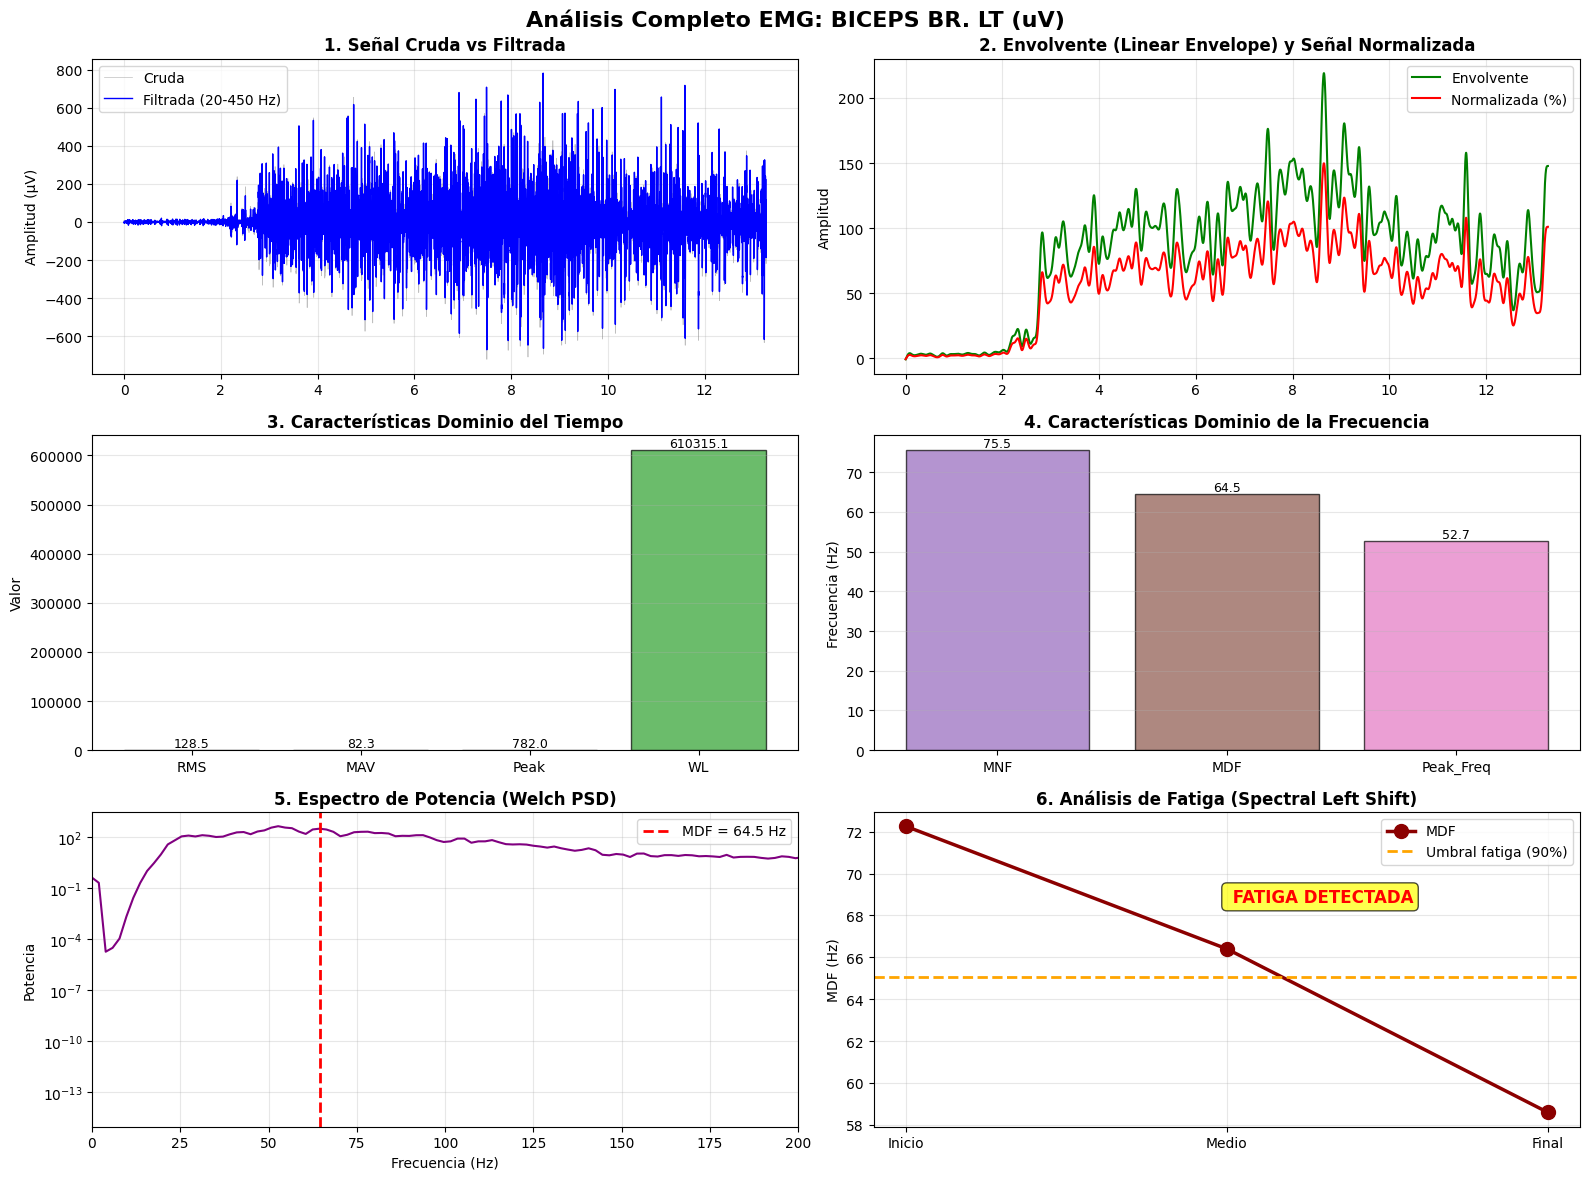


✓ Gráficos mostrados correctamente


In [74]:
# --- VISUALIZACIÓN: 6 GRÁFICOS PRINCIPALES ---
fig, axes = plt.subplots(3, 2, figsize=(16, 12))
fig.suptitle(f'Análisis Completo EMG: {emg_col}', fontsize=16, fontweight='bold')

signals = results['processed_signals']
time_feat = results['time_domain']
freq_feat = results['frequency_domain']
fatigue = results['fatigue']

# 1. Señal Cruda y Filtrada
ax = axes[0, 0]
ax.plot(time, raw_emg, color='gray', alpha=0.5, label='Cruda', linewidth=0.5)
ax.plot(time, signals['filtered'], color='blue', label='Filtrada (20-450 Hz)', linewidth=1)
ax.set_title('1. Señal Cruda vs Filtrada', fontweight='bold')
ax.set_ylabel('Amplitud (µV)')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Envolvente y Normalizada
ax = axes[0, 1]
ax.plot(time, signals['envelope'], color='green', label='Envolvente', linewidth=1.5)
ax.plot(time, signals['normalized'], color='red', label='Normalizada (%)', linewidth=1.5)
ax.set_title('2. Envolvente (Linear Envelope) y Señal Normalizada', fontweight='bold')
ax.set_ylabel('Amplitud')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. Características Temporales (Bar Chart)
ax = axes[1, 0]
time_keys = ['RMS', 'MAV', 'Peak', 'WL']
time_vals = [time_feat.get(k, 0) for k in time_keys]
colors_time = ['#1f77b4', '#ff7f0e', '#d62728', '#2ca02c']
ax.bar(time_keys, time_vals, color=colors_time, alpha=0.7, edgecolor='black')
ax.set_title('3. Características Dominio del Tiempo', fontweight='bold')
ax.set_ylabel('Valor')
ax.grid(True, alpha=0.3, axis='y')
for i, v in enumerate(time_vals):
    ax.text(i, v, f'{v:.1f}', ha='center', va='bottom', fontsize=9)

# 4. Características Espectrales (Bar Chart)
ax = axes[1, 1]
freq_keys = ['MNF', 'MDF', 'Peak_Freq']
freq_vals = [freq_feat.get(k, 0) for k in freq_keys]
colors_freq = ['#9467bd', '#8c564b', '#e377c2']
ax.bar(freq_keys, freq_vals, color=colors_freq, alpha=0.7, edgecolor='black')
ax.set_title('4. Características Dominio de la Frecuencia', fontweight='bold')
ax.set_ylabel('Frecuencia (Hz)')
ax.grid(True, alpha=0.3, axis='y')
for i, v in enumerate(freq_vals):
    ax.text(i, v, f'{v:.1f}', ha='center', va='bottom', fontsize=9)

# 5. Espectro de Potencia (Welch)
ax = axes[2, 0]
ax.semilogy(signals['f_welch'], signals['Pxx_welch'], color='purple', linewidth=1.5)
ax.axvline(freq_feat['MDF'], color='red', linestyle='--', linewidth=2, label=f"MDF = {freq_feat['MDF']:.1f} Hz")
ax.set_title('5. Espectro de Potencia (Welch PSD)', fontweight='bold')
ax.set_xlabel('Frecuencia (Hz)')
ax.set_ylabel('Potencia')
ax.set_xlim(0, 200)
ax.legend()
ax.grid(True, alpha=0.3, which='both')

# 6. Análisis de Fatiga (MDF por segmento)
ax = axes[2, 1]
mdf_vals = [fatigue.get(f'MDF_Segment_{i}', 0) for i in range(3)]
seg_names = ['Inicio', 'Medio', 'Final']
ax.plot(seg_names, mdf_vals, 'o-', color='darkred', linewidth=2.5, markersize=10, label='MDF')
ax.axhline(mdf_vals[0] * FATIGUE_THRESHOLD, color='orange', linestyle='--', 
           linewidth=2, label=f'Umbral fatiga (90%)')
ax.set_title('6. Análisis de Fatiga (Spectral Left Shift)', fontweight='bold')
ax.set_ylabel('MDF (Hz)')
ax.grid(True, alpha=0.3)
ax.legend()

# Marcar si hay fatiga
if fatigue.get('Fatigue_Detected', False):
    ax.text(1, max(mdf_vals) * 0.95, ' FATIGA DETECTADA', 
            fontsize=12, color='red', fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))
else:
    ax.text(1, max(mdf_vals) * 0.95, '✓ MÚSCULO FRESCO', 
            fontsize=12, color='green', fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7))

plt.tight_layout()
plt.show()

print("\n✓ Gráficos mostrados correctamente")

In [75]:
# --- RESUMEN DETALLADO EN CONSOLA ---

print("\n" + "="*80)
print("RESUMEN FINAL DEL ANÁLISIS EMG".center(80))
print("="*80)

print(f"\n INFORMACIÓN DEL ARCHIVO")
print(f"  Columna EMG:    {emg_col}")
print(f"  Duración:       {results['metadata']['duration_s']:.2f} segundos")
print(f"  Muestras:       {results['metadata']['num_samples']:,}")
print(f"  Fs (sampling):  {results['metadata']['fs']} Hz")
print(f"  Método MVC:     {results['metadata']['mvc_method']}")

meta = results['metadata']
raw = results['raw_signal_stats']
print(f"\n ESTADÍSTICAS DE SEÑAL CRUDA")
print(f"  Media:          {raw['mean']:10.2f} µV")
print(f"  Desv. Est.:     {raw['std']:10.2f} µV")
print(f"  Mínimo:         {raw['min']:10.2f} µV")
print(f"  Máximo:         {raw['max']:10.2f} µV")
print(f"  Rango:          {raw['max']-raw['min']:10.2f} µV")

time_feat = results['time_domain']
print(f"\n CARACTERÍSTICAS DOMINIO DEL TIEMPO")
print(f"  RMS:            {time_feat['RMS']:10.4f}  (Potencia)")
print(f"  MAV:            {time_feat['MAV']:10.4f}  (Amplitud media)")
print(f"  Peak:           {time_feat['Peak']:10.4f}  (Máximo absoluto)")
print(f"  WL:             {time_feat['WL']:10.1f}   (Complejidad/cambios)")
print(f"  ZC:             {time_feat['ZC']:10.0f}    (Cruces por cero)")
print(f"  IEMG:           {time_feat['IEMG']:10.2f}   (Energía total)")
print(f"  DAMV:           {time_feat['DAMV']:10.4f}  (Cambio medio)")

freq_feat = results['frequency_domain']
print(f"\n CARACTERÍSTICAS DOMINIO DE LA FRECUENCIA")
print(f"  MNF:            {freq_feat['MNF']:10.2f} Hz  (Frecuencia media)")
print(f"  MDF:            {freq_feat['MDF']:10.2f} Hz  (Frecuencia mediana) ← CLAVE PARA FATIGA")
print(f"  Peak Freq:      {freq_feat['Peak_Freq']:10.2f} Hz  (Frecuencia dominante)")
print(f"  Total Power:    {freq_feat['Total_Power']:10.2e}  (Potencia total)")
print(f"  Power <100Hz:   {freq_feat['Power_Below_100Hz_%']:10.2f} %")

env = results['envelope']
print(f"\n ENVOLVENTE Y NORMALIZACIÓN")
print(f"  Max Envelope:   {env['max']:10.2f} µV")
print(f"  Mean Envelope:  {env['mean']:10.2f} µV")
print(f"  MVC ({env['mvc_method']}):         {env['mvc_value']:10.2f} µV  ← Usar para calibración")
print(f"  Rango normal:   0 - {env['mvc_value']:.2f} µV")

fatigue = results['fatigue']
print(f"\n ANÁLISIS DE FATIGA MUSCULAR (Spectral Left Shift)")
print(f"  MDF Inicio:     {fatigue.get('MDF_Segment_0', 0):10.2f} Hz")
print(f"  MDF Medio:      {fatigue.get('MDF_Segment_1', 0):10.2f} Hz")
print(f"  MDF Final:      {fatigue.get('MDF_Segment_2', 0):10.2f} Hz")
print(f"  Caída MDF:      {fatigue.get('MDF_Drop_%', 0):10.2f} %")
print(f"  Umbral fatiga:  {(1 - FATIGUE_THRESHOLD)*100:10.2f} %")

if fatigue.get('Fatigue_Detected', False):
    print(f"\n   RESULTADO: FATIGA DETECTADA")
    print(f"     El MDF disminuyó más del 10%")
    print(f"     Recomendación: El operario puede estar fatigado")
else:
    print(f"\n   RESULTADO: MÚSCULO FRESCO")
    print(f"     El MDF se mantuvo relativamente estable")
    print(f"     Recomendación: El operario no muestra signos de fatiga")

print("\n" + "="*80)



                         RESUMEN FINAL DEL ANÁLISIS EMG                         

 INFORMACIÓN DEL ARCHIVO
  Columna EMG:    BICEPS BR. LT (uV)
  Duración:       13.28 segundos
  Muestras:       26,559
  Fs (sampling):  2000 Hz
  Método MVC:     95perc

 ESTADÍSTICAS DE SEÑAL CRUDA
  Media:                0.35 µV
  Desv. Est.:         132.10 µV
  Mínimo:            -721.99 µV
  Máximo:             745.39 µV
  Rango:             1467.37 µV

 CARACTERÍSTICAS DOMINIO DEL TIEMPO
  RMS:              128.4916  (Potencia)
  MAV:               82.3352  (Amplitud media)
  Peak:             781.9605  (Máximo absoluto)
  WL:               610315.1   (Complejidad/cambios)
  ZC:                     53    (Cruces por cero)
  IEMG:           2186741.51   (Energía total)
  DAMV:              22.9805  (Cambio medio)

 CARACTERÍSTICAS DOMINIO DE LA FRECUENCIA
  MNF:                 75.52 Hz  (Frecuencia media)
  MDF:                 64.45 Hz  (Frecuencia mediana) ← CLAVE PARA FATIGA
  Peak Freq:       

## Próximos Pasos y Aplicaciones

### Cómo usar este análisis:

**1. Para Control de Robots:**
- Utiliza `results['processed_signals']['normalized']` como entrada de control
- Rango: 0-100% (0% = reposo, 100% = máxima contracción)
- Actualiza cada 100ms para mejor respuesta temporal

**2. Para Detectar Fatiga:**
- Monitorea `MDF` en tiempo real
- Si cae más del 10%, activa alarma o aumenta asistencia del robot
- Útil para prevenir lesiones

**3. Para Análisis de Rendimiento:**
- Compara características entre diferentes usuarios
- Identifica patrones de movimiento anormal
- Evalúa efectividad de entrenamientos

**4. Para Investigación:**
- Extrae todas las características y exporta a CSV
- Compara múltiples registros
- Realiza análisis estadístico

### Archivos generados:
- `EMG_Complete_Analysis.ipynb` - Este notebook (análisis interactivo)
- `EMG_CSV.py` - Script de línea de comandos para batch processing
- `EMG.py` - Script en Tiempo real

In [76]:
# --- EXPORTAR RESULTADOS A CSV ---

import csv

# Crear un diccionario plano con todos los resultados
results_flat = {}

def flatten_dict(d, parent_key=''):
    """Convierte un diccionario anidado en uno plano."""
    for k, v in d.items():
        new_key = f"{parent_key}_{k}" if parent_key else k
        if isinstance(v, dict):
            flatten_dict(v, new_key)
        elif not isinstance(v, np.ndarray):
            results_flat[new_key] = v

flatten_dict(results)

# Guardar a CSV
output_dir = r'C:\Users\alexs\Desktop\EMG_NORAVOX\output'
os.makedirs(output_dir, exist_ok=True)

csv_file = os.path.join(output_dir, 'EMG_Analysis_Results.csv')
with open(csv_file, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['Feature', 'Value'])
    for k, v in results_flat.items():
        if isinstance(v, bool):
            writer.writerow([k, str(v)])
        else:
            writer.writerow([k, v])

print(f"\n[OK] Resultados exportados a: {csv_file}")
print(f"\n[INFO] Caracteristicas guardadas ({len(results_flat)} total):")
for i, key in enumerate(sorted(results_flat.keys()), 1):
    print(f"  {i:2d}. {key}")


[OK] Resultados exportados a: C:\Users\alexs\Desktop\EMG_NORAVOX\output\EMG_Analysis_Results.csv

[INFO] Caracteristicas guardadas (31 total):
   1. envelope_max
   2. envelope_mean
   3. envelope_mvc_method
   4. envelope_mvc_value
   5. envelope_std
   6. fatigue_Fatigue_Detected
   7. fatigue_MDF_Drop_%
   8. fatigue_MDF_Segment_0
   9. fatigue_MDF_Segment_1
  10. fatigue_MDF_Segment_2
  11. fatigue_MDF_Slope
  12. frequency_domain_MDF
  13. frequency_domain_MNF
  14. frequency_domain_Peak_Freq
  15. frequency_domain_Power_Below_100Hz_%
  16. frequency_domain_Total_Power
  17. metadata_duration_s
  18. metadata_fs
  19. metadata_mvc_method
  20. metadata_num_samples
  21. raw_signal_stats_max
  22. raw_signal_stats_mean
  23. raw_signal_stats_min
  24. raw_signal_stats_std
  25. time_domain_DAMV
  26. time_domain_IEMG
  27. time_domain_MAV
  28. time_domain_Peak
  29. time_domain_RMS
  30. time_domain_WL
  31. time_domain_ZC


---
## CITAS


A. Oleinikov, B. Abibullaev, A. Shintemirov y M. Folgheraiter, "Extracción de características y reconocimiento en tiempo real de intenciones de movimiento de la mano a partir de EMGs mediante redes neuronales artificiales," 6ª Conferencia Internacional sobre Interfaz Cerebro-Computadora (BCI) 2018, Gangwon, Corea (Sur), 2018, pp. 1-5, doi: 10.1109/IWW-BCI.2018.8311527. Resumen: El análisis de señales por electromiografía (EMG) es uno de los determinantes clave de la eficacia de los dispositivos protésicos. Los investigadores modernos ofrecen diversos métodos para detectar diferentes movimientos y posturas de las manos. En este trabajo, examinamos la posibilidad de producir una detección eficiente del movimiento de la mano en una postura específica con el menor número posible de electrodos. La adquisición de datos se produce con un sensor BiTalino EMG de 1 canal basado en la medición diferencial bipolar. Utilizando la extracción de características y redes neuronales artificiales, logramos un 82% de precisión de clasificación offline para 8 movimientos de mano y un 91% de precisión para 6 movimientos de mano basados en 200 ms de señal EMG. Además, se desarrolló y probó con éxito el algoritmo de detección de movimiento que permitió implementar el algoritmo para clasificación en tiempo real y mostró suficiente precisión para los casos de 2 y 4 clases de movimiento. palabras  clave: {Electromiografía; Electrodos; Neuronas; Extracción de características; Prótesis; Correlación; análisis en el dominio del tiempo; EMG; Mano; detección de postura; ANN; BiTalino; Blender},URL: https://ieeexplore.ieee.org/stamp/stamp.jsp?tp=&arnumber=8311527&isnumber=8311480  